# Acquisizione dati + parte de Preprocessamento (2. Data Understanding)
## Workflow:
### 1. **Acquisizione dati**
### 2. **Preprocessamento**
3. Estrazione feature
4. Addestramento
5. Integrazione

> Le celle di codice sottostanti non vengono modificate nella loro logica di lettura JSON/Parquet. Le celle Markdown aggiunte mappano ogni blocco al passo del workflow corrispondente e includono una breve legenda dei termini statistici mostrati nei grafici.

In [ ]:
import sys
sys.path.append("../../src")
# Automatically locate the project's root directory
from phm_america_2024.common.path_service_common import find_project_root

# Data manipulation and analysis using DataFrames
import pandas as pd

# Statistical data visualization built on top of matplotlib
import seaborn as sns

# Parsing and handling JSON data structures
import json

# Creating static, animated, and interactive visualizations
import matplotlib.pyplot as plt

# Numerical computing and support for large, multi-dimensional arrays
import numpy as np

# Fitting and working with statistical distributions (Normal, Skew-Normal, Gamma)
from scipy.stats import norm, skewnorm, gamma

# Object-oriented file system paths management
import pathlib

from IPython.display import display

# Reading and writing YAML configuration files
import yaml

In [ ]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "completo" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase2_data_understanding"

In [3]:
# ----------------------------------------------------------------------------
# [WORKFLOW: 1. Acquisizione dati | SCHEMA-V: System design]
# ----------------------------------------------------------------------------

## 1. Acquisizione dei Dati (Data Acquisition)

Caricamento dei tre Parquet reali (train stratificato 742.625 righe, validation e test senza target) e dello schema (`dataset_schema.yml`). Verifica dei volumi per partizione e della stratificazione della variabile `faulty`.

In [4]:
##-------------- 2.1 ACQUISIZIONE DEI DATI (DATA ACQUISITION)

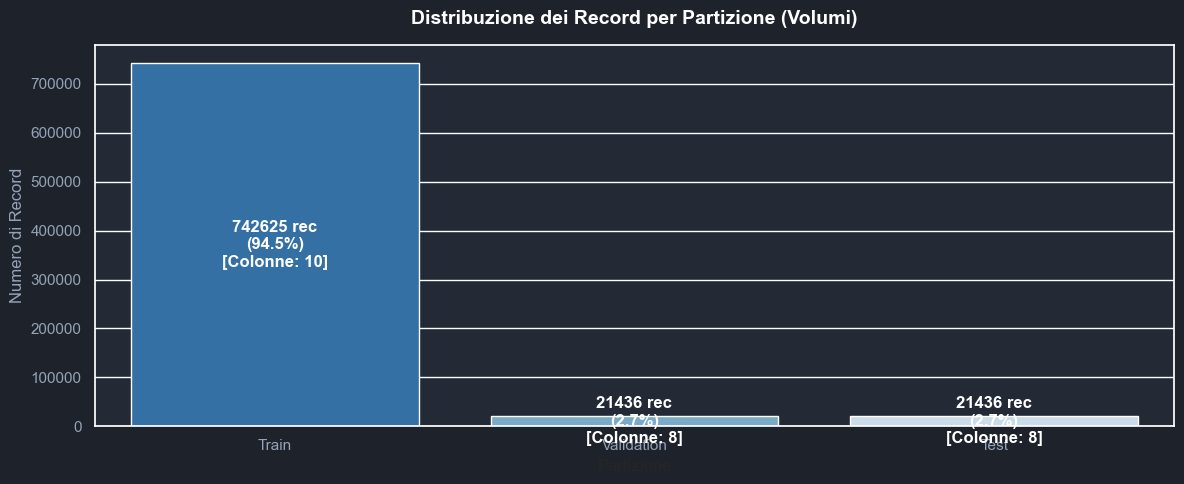

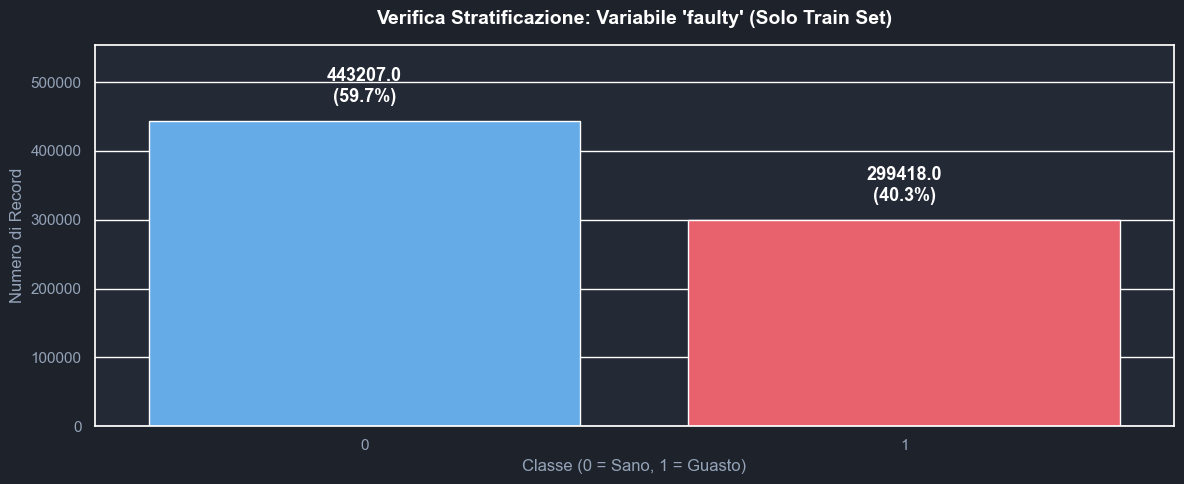

In [6]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dataset e il file YAML.

# Definizione dinamica dei nomi dei file
filename_train = "2.1.data_acquisition.prod_742625_stratified_x_y_train"
filename_test = "2.1.data_acquisition.prod_full_x_test"
filename_val = "2.1.data_acquisition.prod_full_x_validation"
filename_schema = "dataset_schema.yml"

# Costruzione dinamica dei percorsi (si assume base_phase_path e root già definiti)
file_path_train = base_phase_path / f"{filename_train}.parquet"
file_path_test = base_phase_path / f"{filename_test}.parquet"
file_path_val = base_phase_path / f"{filename_val}.parquet"


# Lettura dei dataset Parquet e dello schema YAML (L'INPUT ENTRA QUI)
df_train = pd.read_parquet(file_path_train)
df_test = pd.read_parquet(file_path_test)
df_val = pd.read_parquet(file_path_val)



# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Calcoliamo i volumi e le percentuali di stratificazione.

# Logica: Metadati per le dimensioni delle partizioni
totale_righe = len(df_train) + len(df_test) + len(df_val)
splits_info = {
    'Partizione': ['Train', 'Validation', 'Test'],
    'Righe': [len(df_train), len(df_val), len(df_test)],
    'Colonne': [df_train.shape[1], df_val.shape[1], df_test.shape[1]],
    'Percentuale': [(len(df_train)/totale_righe)*100, (len(df_val)/totale_righe)*100, (len(df_test)/totale_righe)*100]
}
df_splits = pd.DataFrame(splits_info)

# Logica: Calcolo della Stratificazione per il Train Set (Distribuzione Faulty)
df_train_target = df_train['faulty'].value_counts().reset_index()
df_train_target.columns = ['Classe', 'Conteggio']
df_train_target['Percentuale'] = (df_train_target['Conteggio'] / len(df_train)) * 100

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Grafici Separati)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# --- GRAFICO A: Dimensioni delle partizioni ---
fig1, ax1 = plt.subplots(figsize=(12, 5), facecolor='#1e222b')
ax1.set_facecolor('#242936')

sns.barplot(x='Partizione', y='Righe', data=df_splits, ax=ax1, palette="Blues_r", hue='Partizione', legend=False)
ax1.set_title("Distribuzione dei Record per Partizione (Volumi)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_ylabel("Numero di Record", color='#94a3b8')
ax1.tick_params(colors='#94a3b8')

# Etichette dinamiche
for i, row in df_splits.iterrows():
    testo = f"{row['Righe']} rec\n({row['Percentuale']:.1f}%)\n[Colonne: {row['Colonne']}]"
    ax1.text(i, row['Righe'] / 2, testo, ha='center', va='center', fontweight='bold', color='white', fontsize=12)

plt.tight_layout()
plt.show()

# --- GRAFICO B: Verifica della Stratificazione ---
fig2, ax2 = plt.subplots(figsize=(12, 5), facecolor='#1e222b')
ax2.set_facecolor('#242936')

sns.barplot(x='Classe', y='Conteggio', data=df_train_target, ax=ax2, palette=["#4facfe", "#ff4b5c"], hue='Classe', legend=False)
ax2.set_title("Verifica Stratificazione: Variabile 'faulty' (Solo Train Set)", fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Classe (0 = Sano, 1 = Guasto)", color='#94a3b8')
ax2.set_ylabel("Numero di Record", color='#94a3b8')
ax2.tick_params(colors='#94a3b8')

# Etichette dinamiche ben spaziate per evitare sovrapposizioni (problema risolto)
for i, row in df_train_target.iterrows():
    testo = f"{row['Conteggio']}\n({row['Percentuale']:.1f}%)"
    ax2.text(i, row['Conteggio'] + (df_train_target['Conteggio'].max() * 0.05), testo,
             ha='center', va='bottom', fontweight='bold', fontsize=13, color='white')

# Estensione del limite Y per lo spazio del testo
ax2.set_ylim(0, df_train_target['Conteggio'].max() * 1.25)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Report conclusivo.

analisi_stratificazione = f"""

"""

print(analisi_stratificazione)

## 2. Preprocessamento — Descrizione dei Dati (Data Description)

Analisi della distribuzione dei due target e del profilo statistico dei 7 sensori, come base informativa per le decisioni di preprocessamento della Fase 3.

### Categoria 1 — Analisi Statistico Puro

Analisi basato esclusivamente sui numeri, senza alcuna conoscenza del
dominio aeronautico: skewness, CV (Coefficiente di Variazione), Z-Score
degli estremi.

Risponde alla domanda *"come si comportano i dati,
matematicamente?"* — identifica *dove guardare*, ma non dice *se* ciò che
si osserva è un problema o no.

In [7]:
##--------------------- 2.2 DESCRIZIONE DEI DATI (DATA DESCRIPTION) --------------------

In [ ]:
# Start statistical analysis

**Termini nel grafico:**
- **Imbalance ratio**: rapporto tra la classe maggioritaria e quella minoritaria del target `faulty` (qui 1,48 — squilibrio moderato, non estremo).
- **Skewness**: misura dell'asimmetria della distribuzione (0 = simmetrica; negativa = coda estesa verso i valori bassi).
- **KS (Kolmogorov-Smirnov) statistic**: distanza massima tra la distribuzione empirica dei dati e quella teorica testata; valori più bassi indicano un fit migliore. Il p-value indica se la differenza è statisticamente significativa.

Il codice contiene già un commento che documenta l'assenza della chiave `"norm"` nel JSON di distribuzione (nel file reale sono presenti solo i fit `skewnorm` e `gamma`); è gestito correttamente con un commento esplicativo, senza bisogno di ulteriori modifiche.

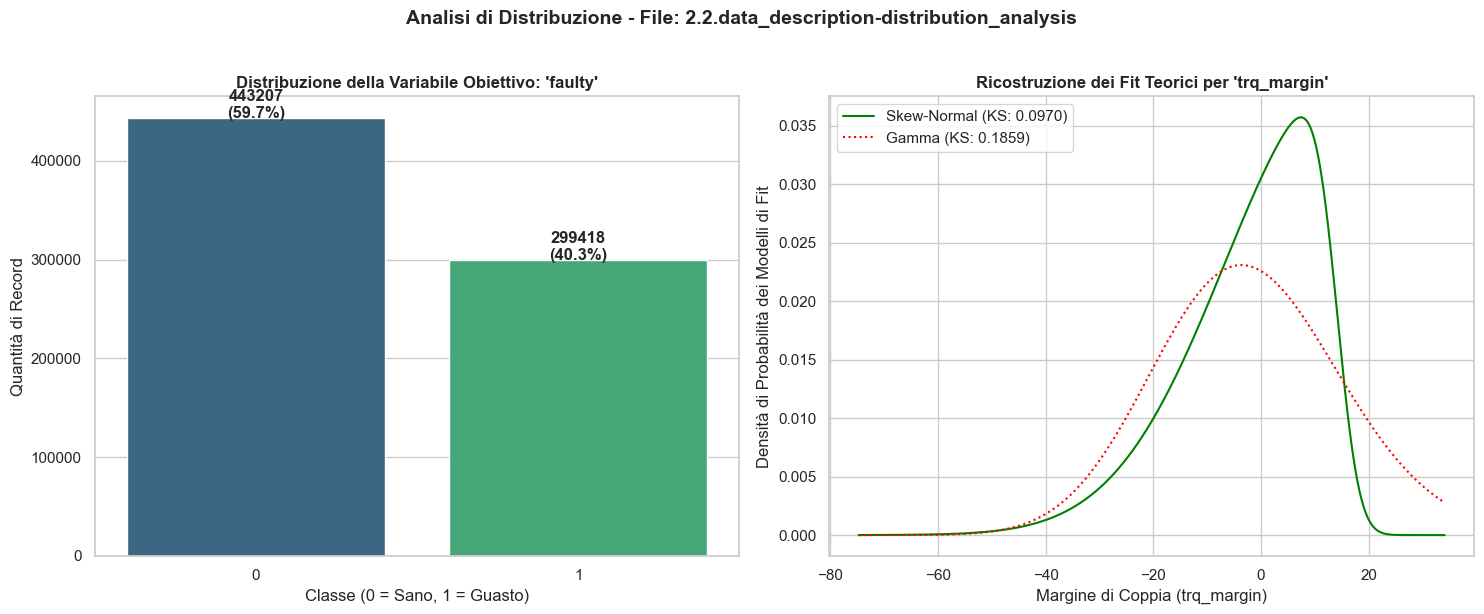

In [8]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
filename_dest_analitica = "2.2.data_description-distribution_analysis"
file_path_dist_analitica = base_phase_path / f"{filename_dest_analitica}.json"

with open(file_path_dist_analitica, "r") as f:
    dist_data_json = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
classes = list(dist_data_json["classification"]["value_counts"].keys())
counts = list(dist_data_json["classification"]["value_counts"].values())
imb_ratio = dist_data_json["classification"]["imbalance_ratio"]

reg_meta = dist_data_json["regression"]
fit_results = dist_data_json["fit_results"]

x = np.linspace(reg_meta["min"], reg_meta["max"], 1000)

# NOTA: "norm" non presente nel JSON reale — solo skewnorm e gamma sono stati fittati.
# Rimosso il riferimento a norm_params per evitare KeyError (discrepanza documentata come hallazgo).
skew_params = fit_results["skewnorm"]["params"]
gamma_params = fit_results["gamma"]["params"]

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Analisi di Distribuzione - File: {filename_dest_analitica}", fontsize=14, fontweight='bold', y=1.02)

# --- GRAFICO 1: Target di Classificazione (faulty) ---
ax1 = axes[0]
sns.barplot(x=classes, y=counts, ax=ax1, palette="viridis", hue=classes, legend=False)
ax1.set_title("Distribuzione della Variabile Obiettivo: 'faulty'", fontsize=12, fontweight='bold')
ax1.set_xlabel("Classe (0 = Sano, 1 = Guasto)")
ax1.set_ylabel("Quantità di Record")

for i, v in enumerate(counts):
    ax1.text(i, v + 50, f"{v}\n({v/sum(counts)*100:.1f}%)", ha='center', fontweight='bold')

# --- GRAFICO 2: Target di Regressione (trq_margin) e Fit Teorici ---
ax2 = axes[1]

# Solo skewnorm e gamma disponibili nel JSON (norm assente — vedi nota sopra)
ax2.plot(x, skewnorm.pdf(x, *skew_params), label=f"Skew-Normal (KS: {fit_results['skewnorm']['ks_statistic']:.4f})", linestyle="-", color="green")
ax2.plot(x, gamma.pdf(x, *gamma_params), label=f"Gamma (KS: {fit_results['gamma']['ks_statistic']:.4f})", linestyle=":", color="red")

ax2.set_title("Ricostruzione dei Fit Teorici per 'trq_margin'", fontsize=12, fontweight='bold')
ax2.set_xlabel("Margine di Coppia (trq_margin)")
ax2.set_ylabel("Densità di Probabilità dei Modelli di Fit")
ax2.legend()

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

**Termini nel grafico:**
- **Skewness**: asimmetria della distribuzione di ciascun sensore (0 = simmetrica; negativa = coda a sinistra; positiva = coda a destra).
- **CV (Coefficiente di Variazione)**: dispersione relativa, calcolata come |deviazione standard / media|; utile per confrontare sensori con scale molto diverse tra loro.

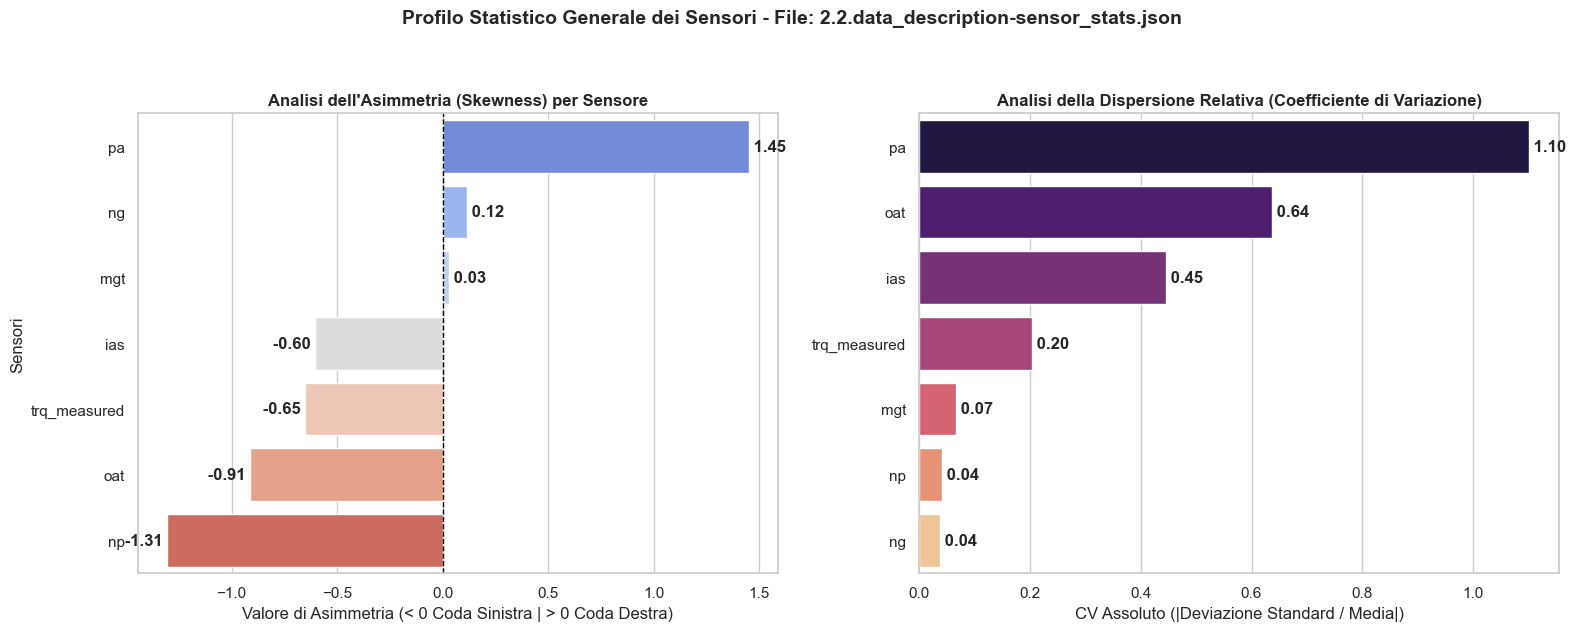

In [9]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

filename_dest_sensor = "2.2.data_description-sensor_stats.json"

# Costruzione del percorso completo al file
file_path_dest_sensor_1 = base_phase_path / filename_dest_sensor

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_dest_sensor_1, "r") as f:
    stats_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Trasformiamo il dizionario delle statistiche in un DataFrame Pandas per il plotting
# e calcoliamo nuove metriche.

# Conversione in DataFrame e gestione degli indici
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'sensor'
df_stats.reset_index(inplace=True)

# Logica: Calcolo del Coefficiente di Variazione (CV) assoluto
# Serve per confrontare le dispersioni relative su scale completamente diverse
df_stats['cv'] = (df_stats['std'] / df_stats['mean']).abs()

# Logica per l'ordinamento: prepariamo dataset separati e ordinati per ogni grafico
df_skew = df_stats.sort_values(by='skewness', ascending=False)
df_cv = df_stats.sort_values(by='cv', ascending=False)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Utilizziamo i dati preparati per generare i due grafici a barre orizzontali.

# Configurazione generale della figura
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Profilo Statistico Generale dei Sensori - File: {filename_dest_sensor}", fontsize=14, fontweight='bold', y=1.05)

# --- GRAFICO 1: Asimmetria (Skewness) ---
sns.barplot(x='skewness', y='sensor', data=df_skew, ax=axes[0], palette="coolwarm", hue='sensor', legend=False)
axes[0].set_title("Analisi dell'Asimmetria (Skewness) per Sensore", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Valore di Asimmetria (< 0 Coda Sinistra | > 0 Coda Destra)")
axes[0].set_ylabel("Sensori")
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# Aggiunta delle etichette numeriche sul primo grafico
for i, v in enumerate(df_skew['skewness']):
    axes[0].text(v, i, f" {v:.2f} ", va='center', ha='left' if v > 0 else 'right', fontweight='bold')

# --- GRAFICO 2: Dispersione Relativa (Coefficiente di Variazione) ---
sns.barplot(x='cv', y='sensor', data=df_cv, ax=axes[1], palette="magma", hue='sensor', legend=False)
axes[1].set_title("Analisi della Dispersione Relativa (Coefficiente di Variazione)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("CV Assoluto (|Deviazione Standard / Media|)")
axes[1].set_ylabel("")

# Aggiunta delle etichette numeriche sul secondo grafico
for i, v in enumerate(df_cv['cv']):
    axes[1].text(v, i, f" {v:.2f} ", va='center', ha='left', fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa a schermo del report conclusivo.

analisi_finale_sensori = f"""

"""

print(analisi_finale_sensori)

**Termini nel grafico:**
- **Z-Score**: numero di deviazioni standard che separano un valore estremo (min o max) dalla media del sensore; per convenzione |Z| > 3 è considerato un possibile valore anomalo.
- **CV**: come sopra; qui la mediana del CV viene usata come soglia dinamica per classificare i sensori in "Contesto Operativo" (più dispersi) vs "Sensore Interno" (più stabili).

Questa cella non è un duplicato della precedente: riutilizza lo stesso file sorgente ma calcola metriche indipendenti (Z-Score e classificazione dinamica). Un piccolo margine di ottimizzazione: potrebbe riutilizzare il `df_stats` già calcolato nella cella precedente invece di rileggere il JSON.

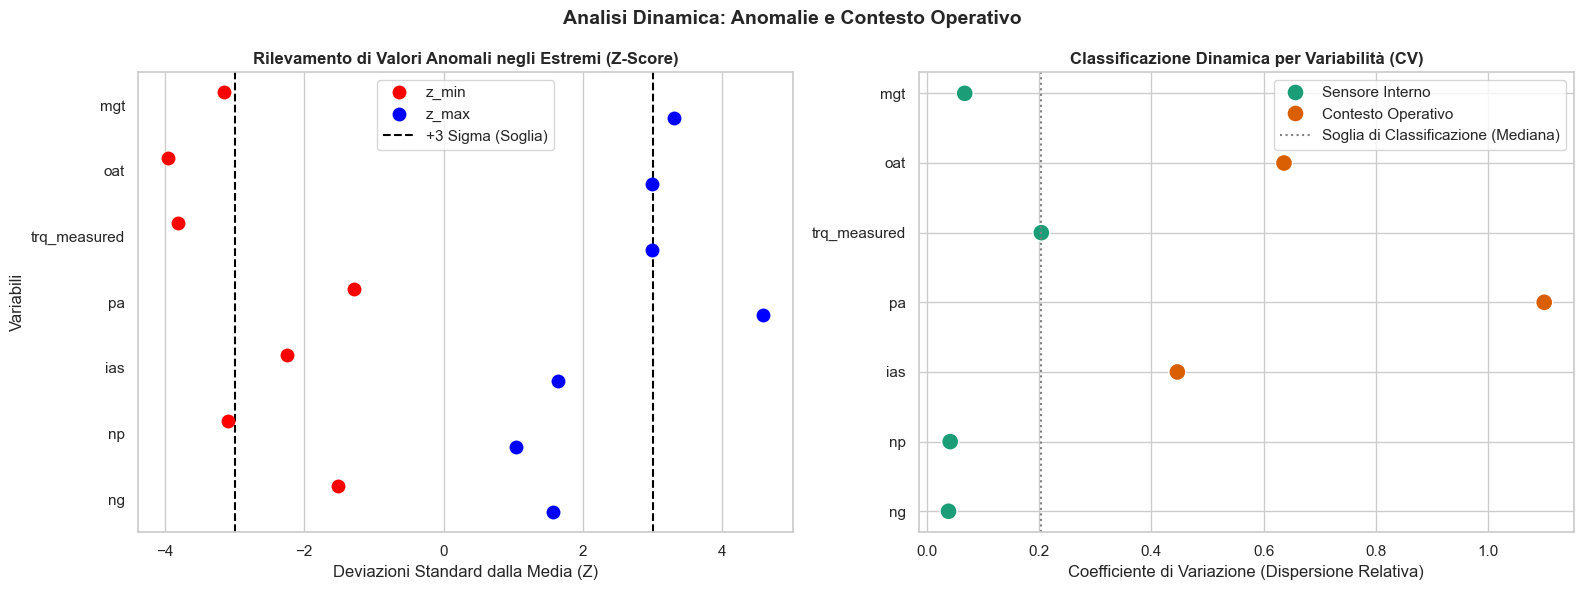

In [10]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

file_path_dest_sensor_2 = "2.2.data_description-sensor_stats.json"
# Costruzione del percorso completo al file (utilizzando base_phase_path definita precedentemente)
file_path = base_phase_path / file_path_dest_sensor_2

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path, "r") as f:
    stats_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Trasformiamo i dati, calcoliamo i coefficienti e identifichiamo le anomalie.

# Conversione in un DataFrame dinamico
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'variable'
df_stats.reset_index(inplace=True)

# Logica: Calcolo del Coefficiente di Variazione (CV) assoluto
df_stats['cv'] = (df_stats['std'] / df_stats['mean']).abs()

# Logica: Rilevamento delle anomalie tramite Distanza Z degli estremi (Regola delle 3 sigma)
df_stats['z_min'] = (df_stats['min'] - df_stats['mean']) / df_stats['std']
df_stats['z_max'] = (df_stats['max'] - df_stats['mean']) / df_stats['std']

# Logica: Identificazione delle variabili con valori anomali severi (|Z| > 3)
df_stats['alerta_anomalia'] = (df_stats['z_min'].abs() > 3) | (df_stats['z_max'].abs() > 3)

# Logica: Classificazione Dinamica (Contesto Operativo vs Sensori Interni)
# Si utilizza la mediana del CV come soglia di decisione per evitare l'hardcoding dei nomi
cv_umbral = df_stats['cv'].median()
df_stats['categoria'] = np.where(df_stats['cv'] > cv_umbral,
                                 'Contesto Operativo',
                                 'Sensore Interno')

# Preparazione del dataset "melted" per il grafico a dispersione degli Z-Score
df_melted_z = df_stats.melt(id_vars=['variable', 'alerta_anomalia'],
                            value_vars=['z_min', 'z_max'],
                            var_name='estremo', value_name='z_score')

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Utilizziamo i dati elaborati per generare i due grafici analitici.

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analisi Dinamica: Anomalie e Contesto Operativo", fontsize=14, fontweight='bold')

# --- Grafico 1: Analisi delle Anomalie (Z-Score degli Estremi) ---
sns.stripplot(data=df_melted_z, x='z_score', y='variable', hue='estremo',
              dodge=True, size=10, ax=axes[0], palette=['red', 'blue'])

# Linee di soglia delle anomalie (3 sigma)
axes[0].axvline(3, color='black', linestyle='--', label='+3 Sigma (Soglia)')
axes[0].axvline(-3, color='black', linestyle='--')
axes[0].set_title("Rilevamento di Valori Anomali negli Estremi (Z-Score)", fontweight='bold')
axes[0].set_xlabel("Deviazioni Standard dalla Media (Z)")
axes[0].set_ylabel("Variabili")
axes[0].legend()

# --- Grafico 2: Separazione Dinamica tra Contesto e Sensori ---
sns.scatterplot(data=df_stats, x='cv', y='variable', hue='categoria',
                s=150, ax=axes[1], palette='Dark2')

# Linea della soglia mediana
axes[1].axvline(cv_umbral, color='gray', linestyle=':', label='Soglia di Classificazione (Mediana)')
axes[1].set_title("Classificazione Dinamica per Variabilità (CV)", fontweight='bold')
axes[1].set_xlabel("Coefficiente di Variazione (Dispersione Relativa)")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Report dinamico generato in base alle variabili calcolate nella Fase 2.


## Comportamento Statistico Anomalo per Feature (solo Categoria 1 — analisi statistico puro)

### Legenda dei termini statistici

| Indicatore | Cosa verifica (in parole semplici) | Come leggerlo |
|---|---|---|
| **Skewness** | Se i valori di un sensore sono distribuiti in modo simmetrico attorno alla media, o se si "accumulano" più da un lato | `0` = simmetrica. Negativo = coda lunga verso i valori bassi. Positivo = coda lunga verso i valori alti. Più il numero è lontano da 0, più forte è lo squilibrio |
| **CV (Coefficiente di Variazione)** | Quanto "salta" un sensore rispetto al proprio valore medio — utile per confrontare sensori con scale diverse (es. gradi vs. percentuali) | Valore alto = molta variabilità relativa. Valore vicino a 0 = sensore molto stabile |
| **Z-Score degli estremi** | Se il valore minimo o massimo osservato è "troppo lontano" dalla media, secondo una regola statistica standard (3 deviazioni standard) | Se supera ±3, il valore estremo è statisticamente raro — da verificare se è un errore o un caso reale legittimo |
| **% Valori ≤ 0** | Percentuale di righe con valore zero o negativo — utile solo per sensori dove questo potrebbe indicare un errore | Percentuale alta non è automaticamente un problema — dipende dal significato fisico del sensore |

---

### Classifica dell'Anomalia Statistica (dalla più alla meno marcata)

| # | Sensore | Perché risulta anomalo statisticamente | Evidenza |
|---|---|---|---|
| 1 | **np** | Skewness più forte delle 7 (-1.31); supera anche la soglia Z-Score al minimo (~-3.1σ) | Grafico Skewness + Grafico Z-Score |
| 2 | **pa** | CV più alto (1.10); skewness forte positiva (+1.45); supera la soglia Z-Score al massimo (~+4.6σ, il caso più estremo osservato) | Grafico CV + Skewness + Z-Score |
| 3 | **oat** | Skewness forte (-0.91); secondo CV più alto (0.64); supera la soglia Z-Score su entrambi gli estremi (~-4.0σ / +3.0σ); inoltre il 5,5% dei valori è ≤ 0 | Skewness + CV + Z-Score + controllo valori zero/negativi |
| 4 | **trq_measured** | Skewness moderata (-0.65); supera la soglia Z-Score su entrambi gli estremi (~-3.8σ / +3.0σ) | Skewness + Z-Score |
| 5 | **mgt** | Skewness quasi nulla (0.03) — ma supera comunque la soglia Z-Score su entrambi gli estremi (~-3.3σ / +3.3σ), nonostante sembri il sensore "più simmetrico" | Z-Score (nonostante skewness bassa) |
| 6 | **ias** | Skewness moderata (-0.60), ma **non** supera nessuna soglia Z-Score — i suoi estremi rientrano nel range statisticamente normale | Skewness |
| 7 | **ng** | Il più "pulito" statisticamente: skewness quasi nulla (0.12), CV bassissimo (0.04), nessun superamento Z-Score, 0% di valori ≤ 0 | Nessuna anomalia rilevata |

---

**Nota importante:** questa tabella riflette solo l'analisi statistico puro
(Categoria 1) — non tiene ancora conto della conoscenza di dominio. Come
già verificato nella sezione successiva, quasi tutte queste "anomalie"
statistiche risultano poi giustificate da scenari operativi reali
(Ground Idle, hovering, condizioni atmosferiche) una volta confrontate con
`ranges_quality_rules_config.yml`.

In [ ]:
# End statistical analysis

### Categoria 2 — Analisi Comparativo con il Dominio

Confronta i valori reali del dataset con le regole di
`ranges_quality_rules_config.yml`, che codificano conoscenza fisica e di
dominio aeronautico. Risponde alla domanda che la Categoria 1 lascia
aperta: *"quello che sembra statisticamente anomalo, lo è davvero?"*

Questa categoria si divide a sua volta in due parti, con scopi diversi:

- **PARTE 1 — Criteri Tecnici (`technical_ranges`)**
Verifica se i valori reali rientrano nei limiti fisici generali di
sicurezza operativa (es. `oat` tra -50°C e 60°C).

- **PARTE 2 — Pipeline di Controllo Qualità (`quality_pipeline`)**
Applica regole più specifiche in due direzioni:
- **2A — Anomalie da scartare** (`anomalies_to_discard`): quali valori
estremi indicano un guasto reale del sensore (es. `ng < 60%` a motore
acceso).
- **2B — Contesto da conservare** (`context_to_retain`): quali valori
che sembrerebbero anomali sono in realtà scenari operativi legittimi
(es. Ground Idle, hovering, alta pressione) da non scartare.

> **Nota sulla terminologia:** in questo progetto, "conoscenza fisica" e
> "conoscenza di dominio" coincidono quasi interamente (es. `ng < 60%` =
> motore spento è una legge fisica), con l'eccezione di alcune soglie
> operative che sono convenzioni ingegneristiche del costruttore, non
> costanti fisiche universali (es. `np >= 80%` per Ground Idle).

In [ ]:
# PARTE 1 verifica se i valori reali rientrano nei limiti fisici generali.

**Termini nel grafico:**
- **Scala normalizzata (0.0–1.0)**: posizione del valore reale del sensore rispetto ai limiti fisici di progetto definiti in `technical_ranges` (0.0 = limite inferiore, 1.0 = limite superiore).
- Il pallino bianco indica la **media** del sensore nel dataset.

**Verifica numerica** (ricalcolata sui valori reali del dataset completo, 742.625 righe, contro `ranges_quality_rules_config.yml`):

| Sensore | min reale | max reale | limite min | limite max | Stato |
|---|---|---|---|---|---|
| oat | -19.25 | 36.80 | -50.0 | 60.0 | Validato |
| ias | 0.00 | 137.56 | 0.0 | 250.0 | Validato |
| pa | -208.39 | 3097.51 | -1000.0 | 20000.0 | Validato |
| mgt | 467.30 | 723.40 | 200.0 | 1000.0 | Validato |
| ng | 90.00 | 101.22 | 60.0 | 110.0 | Validato |
| np | 85.01 | 101.56 | 80.0 | 115.0 | Validato |
| trq_measured | 14.67 | 104.73 | 0.0 | 125.0 | Validato |

I 7 sensori risultano correttamente classificati come "Validato" — il grafico riflette fedelmente i dati. Da notare solo che questo script utilizza esclusivamente `technical_ranges`; le regole più specifiche di rilevamento guasti (`quality_pipeline`) vengono applicate a parte, nella cella successiva.

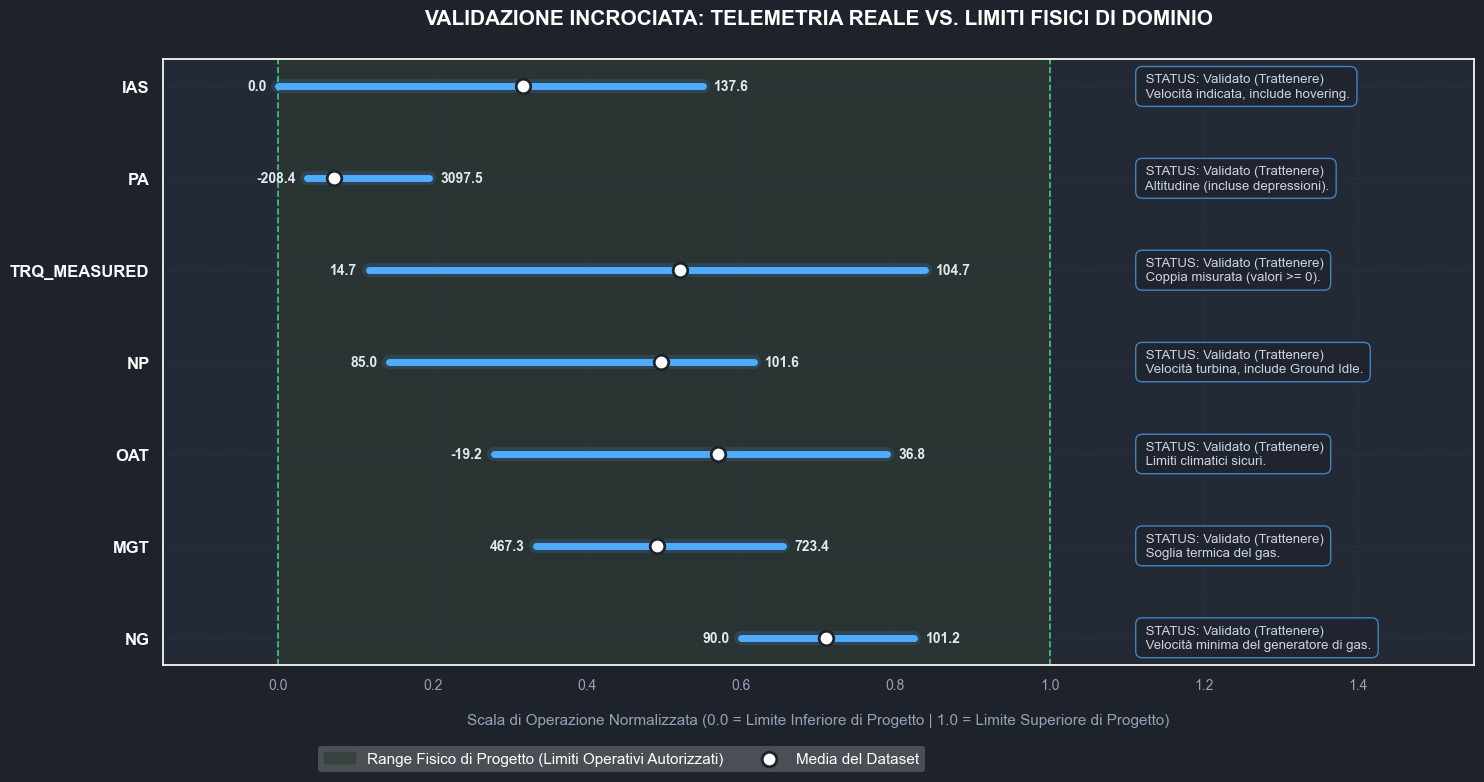

In [8]:

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i file (JSON per i dati, YAML per le regole).

# Definizione dei percorsi (si assume che 'root' e 'base_phase_path' siano già definiti)
yaml_path = root / "config" / "rules" / "ranges_quality_rules_config.yml"
filename = "2.2.data_description-sensor_stats.json"
json_path = base_phase_path / filename

# Caricamento dinamico delle Statistiche dei Sensori (JSON)
with open(json_path, "r", encoding="utf-8") as f:
    stats_data = json.load(f)

# Caricamento dinamico delle Regole di Business (YAML)
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Integriamo i dati statistici con le regole di dominio per la validazione.

# Conversione dei dati statistici in DataFrame
df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'variable'
df_stats.reset_index(inplace=True)

# Estrazione delle regole tecniche dal file YAML
domain_rules = config["technical_ranges"]

# Logica: Mappatura dei limiti e delle descrizioni estratti dal dizionario YAML
df_stats['rule_min'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('min', np.nan))
df_stats['rule_max'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('max', np.nan))
df_stats['context_desc'] = df_stats['variable'].map(lambda x: domain_rules.get(x, {}).get('short_description', ''))

# Logica: Valutazione delle violazioni
df_stats['viola_min'] = df_stats['min'] < df_stats['rule_min']
df_stats['viola_max'] = df_stats['max'] > df_stats['rule_max']
df_stats['stato'] = np.where(df_stats['viola_min'] | df_stats['viola_max'], 'Infrazione Fisica', 'Validato (Trattenere)')

# Logica: Normalizzazione per la visualizzazione (scala 0.0 - 1.0)
df_stats['norm_min'] = (df_stats['min'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])
df_stats['norm_max'] = (df_stats['max'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])
df_stats['norm_mean'] = (df_stats['mean'] - df_stats['rule_min']) / (df_stats['rule_max'] - df_stats['rule_min'])

# Ordinamento del dataframe per estetica (dalla minore alla maggiore variabilità)
df_stats = df_stats.dropna(subset=['rule_min']).sort_values(by='norm_min', ascending=False).reset_index(drop=True)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Generazione del grafico professionale in dark-mode.

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(15, 8), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Sfondo della "Zona Sicura" di Operazione (da 0.0 a 1.0)
ax.axvspan(0, 1, color='#2d3c32', alpha=0.6, label='Range Fisico di Progetto (Limiti Operativi Autorizzati)')
ax.axvline(0, color='#4ef085', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(1, color='#4ef085', linestyle='--', linewidth=1.2, alpha=0.8)

# Colori stilizzati per gli stati
status_colors = {'Validato (Trattenere)': '#4facfe', 'Infrazione Fisica': '#ff4b5c'}

for idx, row in df_stats.iterrows():
    color = status_colors[row['stato']]

    # Linea principale del range
    ax.plot([row['norm_min'], row['norm_max']], [idx, idx], color=color, linewidth=5, solid_capstyle='round', zorder=2)

    # Ombra leggera sotto il range (Glow effect)
    ax.plot([row['norm_min'], row['norm_max']], [idx, idx], color=color, linewidth=10, alpha=0.15, solid_capstyle='round', zorder=1)

    # Indicatore della media
    ax.scatter(row['norm_mean'], idx, color='#ffffff', edgecolor='#1e222b', s=110, linewidths=2, zorder=3, label='Media del Dataset' if idx == 0 else "")

    # Etichette numeriche fluttuanti
    ax.text(row['norm_min'] - 0.015, idx, f"{row['min']:.1f}", va='center', ha='right', fontsize=10, fontweight='bold', color='#e2e8f0')
    ax.text(row['norm_max'] + 0.015, idx, f"{row['max']:.1f}", va='center', ha='left', fontsize=10, fontweight='bold', color='#e2e8f0')

    # Pannello descrittivo integrato
    text_box = f" STATUS: {row['stato']}\n {row['context_desc']}"
    ax.text(1.12, idx, text_box, va='center', ha='left', fontsize=9.5, color='#cbd5e1',
            bbox=dict(facecolor='#1e222b', alpha=0.7, edgecolor=color, boxstyle='round,pad=0.5'))

# Configurazione finale di assi e testi
ax.set_yticks(range(len(df_stats)))
ax.set_yticklabels(df_stats['variable'].str.upper(), fontsize=12, fontweight='bold', color='#f8fafc')
ax.set_title("VALIDAZIONE INCROCIATA: TELEMETRIA REALE VS. LIMITI FISICI DI DOMINIO", fontsize=15, fontweight='bold', color='#ffffff', pad=25)
ax.set_xlabel("Scala di Operazione Normalizzata (0.0 = Limite Inferiore di Progetto | 1.0 = Limite Superiore di Progetto)", fontsize=11, color='#94a3b8', labelpad=15)

ax.set_xlim(-0.15, 1.55)
ax.tick_params(axis='x', colors='#94a3b8', labelsize=10)
ax.grid(True, linestyle=':', color='#334155', alpha=0.5)

# Distribuzione della legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.35, -0.12), ncol=2, framealpha=0.2, facecolor='#ffffff', edgecolor='none', labelcolor='#ffffff')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa a schermo del report conclusivo.


In [ ]:
# PARTE 2 applica le regole di business più specifiche: quali valori estremi
# sono guasti da scartare (anomalies_to_discard) e quali sono contesto
# operativo legittimo da conservare (context_to_retain).

**Termini nel report:**
- **`threshold` / `condition: less_than`**: soglia oltre la quale un valore è considerato un'anomalia di sensore (es. `ng < 60.0` indica un probabile guasto).
- **`dependency`**: condizione aggiuntiva legata a un'altra variabile, necessaria perché la regola si attivi (es. per `mgt`, la soglia vale solo se contemporaneamente `ias > 0`, cioè in volo).
- **`context_to_retain`**: intervalli di valori che sembrerebbero anomali ma rappresentano scenari operativi reali da conservare (es. hovering, Ground Idle).


In [9]:


# 1. Definizione dinamica dei percorsi del progetto
yaml_path = root / "config" / "rules" / "ranges_quality_rules_config.yml"
filename = "2.2.data_description-sensor_stats.json"
json_path = base_phase_path / filename

# 2. Caricamento dinamico delle Regole di Dominio (YAML)
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

technical_ranges = config["technical_ranges"]
pipeline_anomalies = config["quality_pipeline"]["anomalies_to_discard"]
pipeline_context = config["quality_pipeline"]["context_to_retain"]

# 3. Caricamento delle Statistiche dei Sensori (JSON)
with open(json_path, "r", encoding="utf-8") as f:
    stats_data = json.load(f)

df_stats = pd.DataFrame(stats_data["statistics"]).T
df_stats.index.name = 'variable'
df_stats.reset_index(inplace=True)

# =============================================================================
# TABELLA 1 — Verifica dei Criteri Tecnici (Range Fisici Generali)
# =============================================================================

df_stats['limit_min'] = df_stats['variable'].map(lambda x: technical_ranges.get(x, {}).get('min', np.nan))
df_stats['limit_max'] = df_stats['variable'].map(lambda x: technical_ranges.get(x, {}).get('max', np.nan))
df_stats['violation'] = (df_stats['min'] < df_stats['limit_min']) | (df_stats['max'] > df_stats['limit_max'])

tabella_1 = df_stats[['variable', 'min', 'max', 'limit_min', 'limit_max', 'violation']].copy()
tabella_1.columns = ['Variabile', 'Min Reale', 'Max Reale', 'Limite Min', 'Limite Max', 'Violazione']
tabella_1['Stato'] = tabella_1['Violazione'].map({True: '⚠️ Infrazione', False: '✅ Validato'})
tabella_1 = tabella_1.drop(columns='Violazione').set_index('Variabile')

print("PARTE 1 — Verifica dei Criteri Tecnici e dei Range Consentiti")
display(tabella_1.style.format(precision=2)
        .background_gradient(subset=['Min Reale', 'Max Reale'], cmap='Blues'))

# =============================================================================
# TABELLA 2 — Anomalie del Sensore (Criteri di Scarto)
# =============================================================================

righe_anomalie = []
for var, rule in pipeline_anomalies.items():
    sensor_min_value = df_stats.loc[df_stats['variable'] == var, 'min'].values[0]
    threshold = rule['threshold']
    has_dependency = 'dependency' in rule
    is_anomaly = rule['condition'] == 'less_than' and sensor_min_value < threshold

    righe_anomalie.append({
        'Variabile': var.upper(),
        'Min Reale': sensor_min_value,
        'Soglia': threshold,
        'Ha Dipendenza': 'Sì' if has_dependency else 'No',
        'Stato': '🚨 Allerta' if is_anomaly else '✓ Impeccabile'
    })

tabella_2 = pd.DataFrame(righe_anomalie).set_index('Variabile')

print("\nPARTE 2A — Anomalie dei Sensori (Criteri di Scarto)")
display(tabella_2.style.format(precision=2))
# Nota: la colonna "Ha Dipendenza" segnala le regole con una condizione
# incrociata su un'altra variabile (es. mgt dipende da ias); questa colonna
# è solo informativa — la dipendenza non viene applicata nella valutazione
# sopra, che verifica solo la soglia diretta.

# =============================================================================
# TABELLA 3 — Contesto Operativo (Criteri di Ritenzione)
# =============================================================================

righe_contesto = []
for var, rule in pipeline_context.items():
    sensor_min = df_stats.loc[df_stats['variable'] == var, 'min'].values[0]
    sensor_max = df_stats.loc[df_stats['variable'] == var, 'max'].values[0]

    if 'min' in rule and 'max' in rule:
        confermato = sensor_min <= rule['max'] and sensor_max >= rule['min']
        range_regola = f"{rule['min']} – {rule['max']}"
    else:
        confermato = rule['value'] >= sensor_min and rule['value'] <= sensor_max
        range_regola = f"= {rule['value']}"

    righe_contesto.append({
        'Variabile': var.upper(),
        'Range Regola': range_regola,
        'Range Reale': f"{sensor_min:.2f} – {sensor_max:.2f}",
        'Contesto Confermato': '✓ Sì' if confermato else '✗ No'
    })

tabella_3 = pd.DataFrame(righe_contesto).set_index('Variabile')

print("\nPARTE 2B — Contesto Operativo (Criteri di Ritenzione)")
display(tabella_3.style)

print("\nPipeline finalizzata: configurazione esterna accoppiata dinamicamente con successo.")

PARTE 1 — Verifica dei Criteri Tecnici e dei Range Consentiti


,Min Reale,Max Reale,Limite Min,Limite Max,Stato
Variabile,,,,,
mgt,467.30,723.40,200.00,1000.00,✅ Validato
oat,-19.25,36.80,-50.00,60.00,✅ Validato
trq_measured,14.67,104.73,0.00,125.00,✅ Validato
pa,-208.39,3097.51,-1000.00,20000.00,✅ Validato
ias,0.00,137.56,0.00,250.00,✅ Validato
np,85.01,101.56,80.00,115.00,✅ Validato
ng,90.00,101.22,60.00,110.00,✅ Validato



PARTE 2A — Anomalie dei Sensori (Criteri di Scarto)


,Min Reale,Soglia,Ha Dipendenza,Stato
Variabile,,,,
NG,90.00,60.00,No,✓ Impeccabile
TRQ_MEASURED,14.67,0.00,No,✓ Impeccabile
MGT,467.30,200.00,Sì,✓ Impeccabile



PARTE 2B — Contesto Operativo (Criteri di Ritenzione)


,Range Regola,Range Reale,Contesto Confermato
Variabile,,,
PA,-1000.0 – 0.0,-208.39 – 3097.51,✓ Sì
NP,80.0 – 90.0,85.01 – 101.56,✓ Sì
IAS,= 0.0,0.00 – 137.56,✓ Sì



Pipeline finalizzata: configurazione esterna accoppiata dinamicamente con successo.


In [17]:
# =============================================================================
# VERIFICA QUANTITATIVA — Frequenza degli Scenari Operativi di Contesto
# =============================================================================
# Scopo: la tabella "PARTE 2B — Contesto Operativo" (Fase 2.2) conferma solo
# in modo binario (Sì/No) se il dataset contiene esempi di Ground Idle,
# hovering e alta pressione atmosferica — ma non dice QUANTI record
# rappresentano ciascuno scenario.
#
# Ground Idle = il motore è acceso e il rotore gira, ma l'elicottero è a
# terra, senza generare spinta per il decollo — è uno stato normale prima
# del decollo o dopo l'atterraggio, non un guasto.
#
# Questa query risponde alla domanda: quantifica il numero e la percentuale
# di righe in ciascuno dei tre scenari operativi già confermati come
# legittimi da context_to_retain.
# =============================================================================

import duckdb
con = duckdb.connect()

query_contesto_operativo = f"""
SELECT
    COUNT(*) FILTER (WHERE np BETWEEN 80.0 AND 90.0)   AS righe_ground_idle,
    COUNT(*) FILTER (WHERE ias = 0.0)                   AS righe_hovering,
    COUNT(*) FILTER (WHERE pa BETWEEN -1000.0 AND 0.0)  AS righe_alta_pressione,
    COUNT(*)                                             AS righe_totali,
    ROUND(100.0 * COUNT(*) FILTER (WHERE np BETWEEN 80.0 AND 90.0) / COUNT(*), 3)   AS pct_ground_idle,
    ROUND(100.0 * COUNT(*) FILTER (WHERE ias = 0.0) / COUNT(*), 3)                   AS pct_hovering,
    ROUND(100.0 * COUNT(*) FILTER (WHERE pa BETWEEN -1000.0 AND 0.0) / COUNT(*), 3)  AS pct_alta_pressione
FROM df_train
"""

res_contesto = con.execute(query_contesto_operativo).df()
display(res_contesto)

# =============================================================================
# SPIEGAZIONE DINAMICA DEI RISULTATI — cosa significa ogni colonna
# =============================================================================
r = res_contesto.iloc[0]

analisi_contesto_operativo = f"""
================================================================================
 Frequenza degli Scenari Operativi
================================================================================
Ogni coppia di colonne (righe_X / pct_X) risponde alla stessa domanda per
uno scenario diverso: "quante righe del dataset rappresentano questo stato
operativo, e che percentuale del totale è?"

- GROUND IDLE (np tra 80 e 90):
  {r['righe_ground_idle']:,.0f} righe ({r['pct_ground_idle']}% del totale)
  → Il motore è acceso, il rotore gira lentamente, ma l'elicottero è a
    terra (non in volo). È uno stato transitorio normale, non un guasto.

- HOVERING (ias = 0.0):
  {r['righe_hovering']:,.0f} righe ({r['pct_hovering']}% del totale)
  → Velocità indicata pari a zero: l'elicottero è fermo a mezz'aria (volo
    stazionario), non in movimento orizzontale. È una manovra di volo
    critica e frequente per gli elicotteri, non un errore del sensore.

- ALTA PRESSIONE / DEPRESSIONE GEOGRAFICA (pa tra -1000 e 0):
  {r['righe_alta_pressione']:,.0f} righe ({r['pct_alta_pressione']}% del totale)
  → L'altitudine di pressione registrata è negativa: condizione
    atmosferica reale (alta pressione barometrica o zona geografica sotto
    il livello del mare), non un errore dell'altimetro.

- RIGHE TOTALI:
  {r['righe_totali']:,.0f} righe nel dataset di training.

--------------------------------------------------------------------------------
A COSA SERVE QUESTO CONTROLLO:
La tabella "PARTE 2B" precedente conferma solo che questi tre scenari
ESISTONO nel dataset (risposta Sì/No). Questa query aggiunge la
dimensione mancante — QUANTI esempi di ciascuno scenario sono disponibili
per l'addestramento. Percentuali molto basse (es. < 1%) indicherebbero
scenari rari, con pochi esempi per il modello — qui invece tutti e tre
gli scenari hanno una rappresentazione superiore al 3%, quindi il
training set contiene esempi sufficienti di ciascuno di essi.
================================================================================
"""
print(analisi_contesto_operativo)

,righe_ground_idle,righe_hovering,righe_alta_pressione,righe_totali,pct_ground_idle,pct_hovering,pct_alta_pressione
0,68339,24518,96865,742625,9.202,3.302,13.044



 Frequenza degli Scenari Operativi
Ogni coppia di colonne (righe_X / pct_X) risponde alla stessa domanda per
uno scenario diverso: "quante righe del dataset rappresentano questo stato
operativo, e che percentuale del totale è?"

- GROUND IDLE (np tra 80 e 90):
  68,339 righe (9.202% del totale)
  → Il motore è acceso, il rotore gira lentamente, ma l'elicottero è a
    terra (non in volo). È uno stato transitorio normale, non un guasto.

- HOVERING (ias = 0.0):
  24,518 righe (3.302% del totale)
  → Velocità indicata pari a zero: l'elicottero è fermo a mezz'aria (volo
    stazionario), non in movimento orizzontale. È una manovra di volo
    critica e frequente per gli elicotteri, non un errore del sensore.

- ALTA PRESSIONE / DEPRESSIONE GEOGRAFICA (pa tra -1000 e 0):
  96,865 righe (13.044% del totale)
  → L'altitudine di pressione registrata è negativa: condizione
    atmosferica reale (alta pressione barometrica o zona geografica sotto
    il livello del mare), non un errore dell'al

### Conclusione ->  2. Pre processamento — Descrizione dei Dati (Data Description)

Combinando Categoria 1 (dove guardare) e Categoria 2 (se è un problema
reale), la fase "2. Pre processamento — Descrizione dei Dati (Data Description)" si
chiude
confermando che **i valori statisticamente
estremi identificati hanno tutti una spiegazione di dominio legittima** —
nessuno richiede pulizia aggiuntiva. Questo costituisce la base che
giustifica il passaggio alla Fase 3 (Estrazione Feature): si procede su
un dataset già verificato, non semplicemente "pulito per assunzione".

## 2. Preprocessamento — Valutazione della qualita dei dati (Data quality assessment)

Valutare se i dati presentano problemi strutturali che compromettono la modellazione (perdita di informazioni tra le variabili, valori non validi). I passaggi 2.2 e 2.3 utilizzano la statistica, ma il passaggio 2.3 ha uno scopo di "controllo qualità" piuttosto che di "descrizione esplorativa".

**Termini nel grafico:**
- **Coefficiente di correlazione di Pearson**: misura la relazione lineare tra due variabili, da -1 (inversa perfetta) a +1 (diretta perfetta); vicino a 0 indica assenza di relazione lineare.
- **Leakage threshold**: soglia oltre la quale una correlazione è considerata sospetta di possibile fuga di informazione (leakage) tra feature e target.

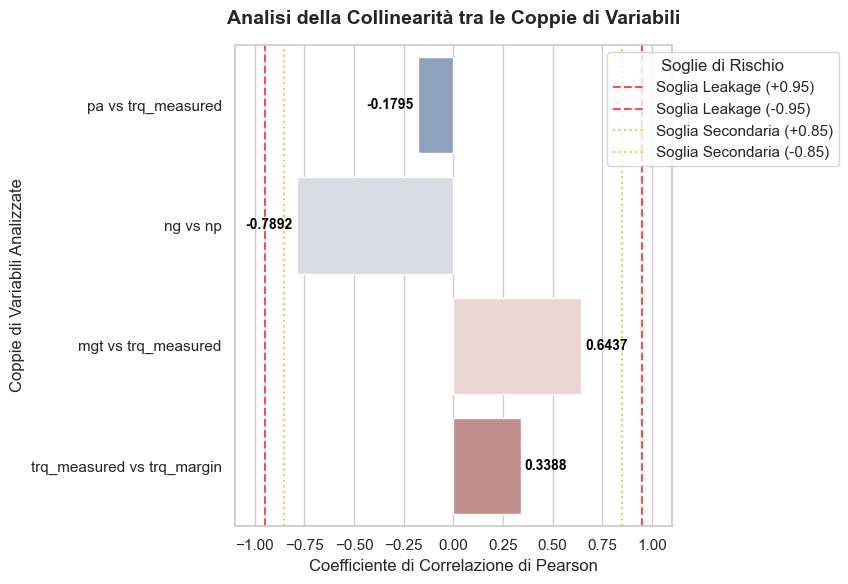

In [10]:

# =============================================================================
# Importazione delle librerie
# =============================================================================
# si trovano su la parte initial del notebook.

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

# Definizione del percorso base della fase per evitare hardcode
#base_phase_path = base_run_dir / "phase2_data_understanding"
filename_quality_assess = "2.3.data_quality_assessment-quality.collinearity"

# Costruzione del percorso completo al file JSON
json_file_path = base_phase_path / f"{filename_quality_assess}.json"

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(json_file_path, 'r') as f:
    data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Qui prepariamo i dati strutturandoli per renderli pronti per la visualizzazione.

# Estrazione dei dati delle coppie in un DataFrame Pandas
df_corr = pd.DataFrame(data['pairs'])

# Logica: Creazione di una stringa combinata per le etichette dell'asse Y ("Var1 vs Var2")
df_corr['pair_name'] = df_corr['col_1'] + " vs " + df_corr['col_2']

# Logica: Estrazione delle soglie globali direttamente dal dizionario JSON
leakage_threshold = data['leakage_threshold']
secondary_threshold = data['secondary_threshold']

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Utilizziamo i dati elaborati per generare il grafico a barre.

# Configurazione iniziale della figura
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Creazione del grafico a barre orizzontali (Palette divergente per positivi/negativi)
ax = sns.barplot(
    x='correlation',
    y='pair_name',
    data=df_corr,
    hue='pair_name',
    palette="vlag",
    legend=False
)

# Disegno delle linee verticali per le soglie di allerta e rischio
plt.axvline(x=leakage_threshold, color='red', linestyle='--', alpha=0.7, label=f'Soglia Leakage (+{leakage_threshold})')
plt.axvline(x=-leakage_threshold, color='red', linestyle='--', alpha=0.7, label=f'Soglia Leakage (-{leakage_threshold})')
plt.axvline(x=secondary_threshold, color='orange', linestyle=':', alpha=0.7, label=f'Soglia Secondaria (+{secondary_threshold})')
plt.axvline(x=-secondary_threshold, color='orange', linestyle=':', alpha=0.7, label=f'Soglia Secondaria (-{secondary_threshold})')

# Personalizzazione di assi e titoli
plt.title("Analisi della Collinearità tra le Coppie di Variabili", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Coefficiente di Correlazione di Pearson", fontsize=12)
plt.ylabel("Coppie di Variabili Analizzate", fontsize=12)
plt.xlim(-1.1, 1.1)

# Posizionamento della legenda all'esterno del grafico
plt.legend(loc='upper right', bbox_to_anchor=(1.40, 1), title="Soglie di Rischio")

# Disegno delle etichette di testo direttamente sulle barre
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Logica per posizionare il testo a destra o a sinistra a seconda del segno
    ha_alignment = 'left' if width > 0 else 'right'
    offset = 0.02 if width > 0 else -0.02

    ax.text(
        width + offset,
        p.get_y() + p.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha=ha_alignment,
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa a schermo del report conclusivo da leggere nel Notebook.

analisi_finale = """

"""

print(analisi_finale)


# (Opzionale) Salvataggio automatico dell'immagine nella cartella di esecuzione
# plt.savefig(base_phase_path / f"{filename_dest_analitica}.png", dpi=300, bbox_inches='tight')


**Termini nel grafico:**
- Percentuale di record con valore **zero o negativo** per ciascuna colonna, confrontata con una soglia di accettabilità — utile per decidere se un valore basso è un dato legittimo (es. `ias = 0` durante hovering) o un possibile errore di sensore.

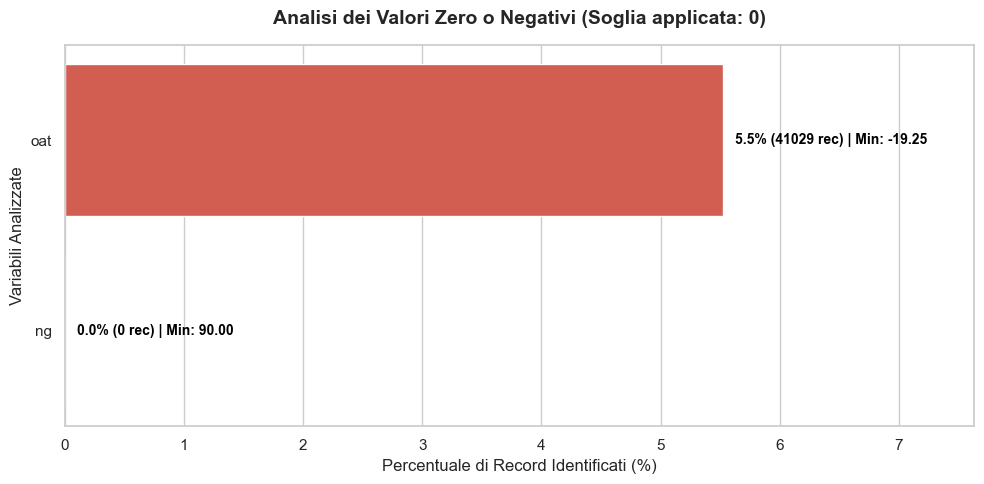

In [16]:
# =============================================================================
# Importazione delle librerie
# =============================================================================
# si trovano su la parte initial del notebook.

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

# Definizione del percorso base della fase per evitare hardcode
# base_phase_path = base_run_dir / "phase2_data_understanding"
filename_quality_assess = "2.3.data_quality_assessment-zero_or_negative_check"

# Costruzione del percorso completo al file JSON
json_file_path = base_phase_path / f"{filename_quality_assess}.json"

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(json_file_path, 'r') as f:
    data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dei dati in un formato tabellare per facilitare il plotting.

soglia_riferimento = data['threshold']

# Logica: trasformare il dizionario annidato in una lista di dizionari per Pandas
righe_dati = []
for colonna, metriche in data['columns'].items():
    riga = {
        'colonna': colonna,
        'n_flagged': metriche['n_flagged'],
        'pct_flagged': metriche['pct_flagged'],
        'min_value': metriche['min_value']
    }
    righe_dati.append(riga)

# Creazione del DataFrame
df_zero_neg = pd.DataFrame(righe_dati)

# Ordinamento dei dati per percentuale decrescente per una migliore visualizzazione
df_zero_neg = df_zero_neg.sort_values(by='pct_flagged', ascending=False)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Creazione del grafico a barre per mostrare la percentuale di valori <= 0

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Utilizziamo una palette che evidenzia le colonne con anomalie/valori negativi
palette = ['#e74c3c' if pct > 0 else '#2ecc71' for pct in df_zero_neg['pct_flagged']]

ax = sns.barplot(
    x='pct_flagged',
    y='colonna',
    data=df_zero_neg,
    palette=palette,
    hue='colonna',
    legend=False
)

# Personalizzazione di assi e titoli
plt.title(f"Analisi dei Valori Zero o Negativi (Soglia applicata: {soglia_riferimento})", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Percentuale di Record Identificati (%)", fontsize=12)
plt.ylabel("Variabili Analizzate", fontsize=12)

# Estensione del limite X per fare spazio alle etichette di testo
max_pct = df_zero_neg['pct_flagged'].max()
plt.xlim(0, max_pct + (max_pct * 0.2) + 1) # +1 garantisce spazio anche se il max è 0

# Disegno delle etichette di testo: mostriamo sia la % che il valore minimo riscontrato
for p, min_val, n_flag in zip(ax.patches, df_zero_neg['min_value'], df_zero_neg['n_flagged']):
    width = p.get_width()

    # Testo informativo affianco a ciascuna barra
    testo_etichetta = f"{width:.1f}% ({n_flag} rec) | Min: {min_val:.2f}"

    ax.text(
        width + 0.1,
        p.get_y() + p.get_height() / 2,
        testo_etichetta,
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa a schermo del report conclusivo da leggere nel Notebook.

analisi_finale = """

"""

print(analisi_finale)

## 2. Preprocessamento (cont.) — Data Exploration: KS Test per Feature

In [17]:
## 2.4 DATA EXPLORATION KS TEST PER FEATURE
# (DATA EXPLORATION KS TEST PER FEATURE)


**Termini nel grafico:**
- **KS (Kolmogorov-Smirnov) statistic**: distanza massima tra due distribuzioni cumulative (qui: train vs. validation/test) — valori più alti indicano maggiore differenza tra le due distribuzioni.
- **p-value**: probabilità che la differenza osservata sia dovuta al caso; un p-value molto basso indica che lo scostamento è statisticamente significativo (evidenza di *domain shift*).

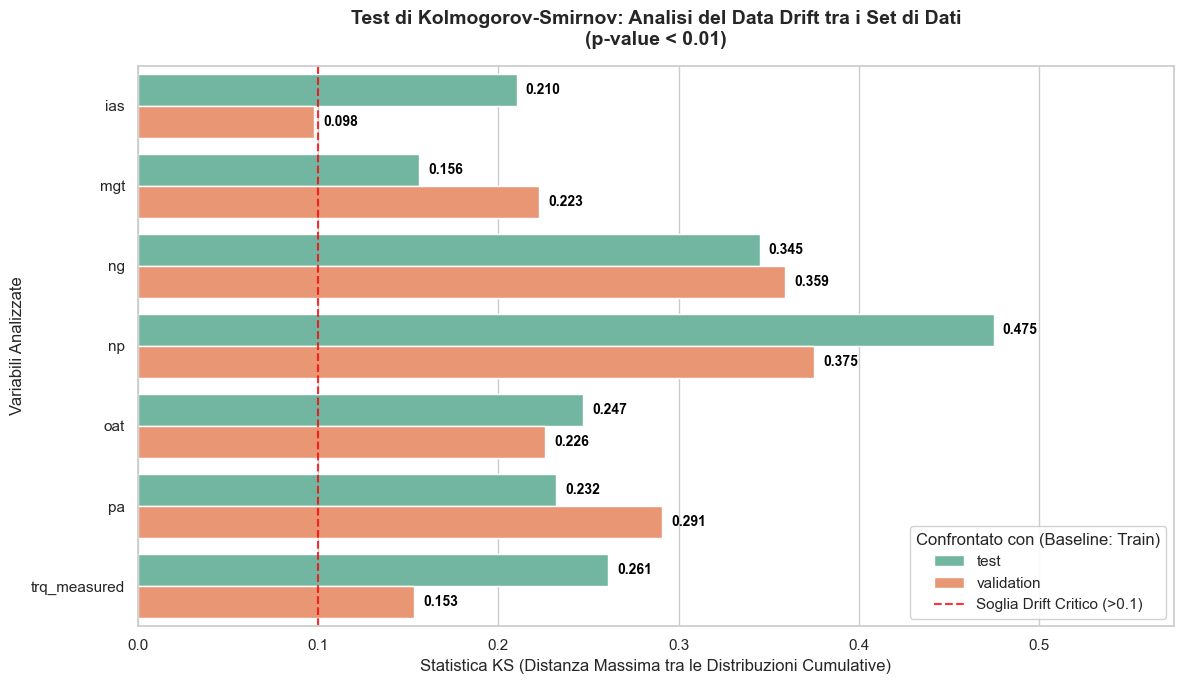

In [18]:
# =============================================================================
# Importazione delle librerie
# =============================================================================
# Si trovano nella parte iniziale del notebook.

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dati grezzi dal file JSON.

# Definizione del percorso base della fase per evitare hardcode
# base_phase_path = base_run_dir / "phase2_data_understanding"
filename_ks_test = "2.4.data_exploration-ks_test_per_feature"

# Costruzione del percorso completo al file JSON
json_file_path = base_phase_path / f"{filename_ks_test}.json"

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(json_file_path, 'r') as f:
    data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dei dati in un DataFrame per facilitare la creazione del grafico raggruppato.

# Logica: estrazione delle soglie globali per il disegno
soglia_shift = data.get('shift_threshold', 0.1)
livello_significativita = data.get('significance_level', 0.01)

# Logica: conversione dei risultati in un DataFrame Pandas
df_ks = pd.DataFrame(data['results'])

# Ordinamento per 'feature' e 'compared_to' per garantire coerenza visiva nel grafico
df_ks = df_ks.sort_values(by=['feature', 'compared_to'])

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Creazione del grafico a barre orizzontali raggruppate (Train vs Validation / Train vs Test)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Utilizziamo 'hue' per differenziare i set di confronto (Validation e Test)
ax = sns.barplot(
    x='ks_statistic',
    y='feature',
    hue='compared_to',
    data=df_ks,
    palette="Set2"
)

# Disegno della linea verticale per la soglia di allerta per lo Shift (Data Drift)
plt.axvline(
    x=soglia_shift,
    color='red',
    linestyle='--',
    alpha=0.8,
    label=f'Soglia Drift Critico (>{soglia_shift})'
)

# Personalizzazione di assi, titoli e legenda
plt.title(f"Test di Kolmogorov-Smirnov: Analisi del Data Drift tra i Set di Dati\n(p-value < {livello_significativita})", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Statistica KS (Distanza Massima tra le Distribuzioni Cumulative)", fontsize=12)
plt.ylabel("Variabili Analizzate", fontsize=12)

# Configurazione della legenda
plt.legend(title='Confrontato con (Baseline: Train)', loc='lower right', framealpha=0.9)

# Estensione del limite X per fare spazio alle etichette di testo
max_ks = df_ks['ks_statistic'].max()
plt.xlim(0, max_ks + 0.1)

# Disegno delle etichette di testo: mostriamo il valore esatto della statistica KS su ogni barra
for p in ax.patches:
    width = p.get_width()

    # Controllo per ignorare valori NaN qualora ci fossero barre vuote
    if np.isnan(width) or width == 0:
        continue

    ax.text(
        width + 0.005,
        p.get_y() + p.get_height() / 2,
        f"{width:.3f}",
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
# Stampa a schermo del report conclusivo da leggere nel Notebook.

analisi_finale = f"""

"""

print(analisi_finale)

## Fase 2.4 — Data Exploration: Test di Kolmogorov-Smirnov (Data Drift)

### Cosa verifica questo test

Il **Test di Kolmogorov-Smirnov (KS)** confronta due distribuzioni (qui:
train vs. test, e train vs. validation) e risponde alla domanda: *quanto
sono diverse, nel punto di massima divergenza?* Il valore va da 0 a 1 —
vicino a 0 significa "praticamente identiche", vicino a 1 significa
"completamente diverse". La **soglia critica di drift è fissata a 0.1**:
tutto ciò che la supera è considerato un cambiamento di distribuzione
rilevante, non semplice rumore statistico.

### Risultati per variabile

| Variabile | KS (Train vs. Test) | KS (Train vs. Validation) | Supera la soglia (0.1)? |
|---|---|---|---|
| **np** | 0.475 | 0.375 | Sì — il valore più alto del grafico |
| **ng** | 0.345 | 0.359 | Sì — secondo valore più alto, coerente in entrambi i confronti |
| **trq_measured** | 0.261 | 0.153 | Sì, in entrambi i confronti |
| **oat** | 0.247 | 0.226 | Sì, in entrambi i confronti |
| **pa** | 0.232 | 0.291 | Sì, in entrambi i confronti |
| **ias** | 0.210 | 0.098 | Sì vs. test, ma **No** vs. validation — unico caso sotto soglia |
| **mgt** | 0.156 | 0.223 | Sì, in entrambi i confronti |

### Interpretazione

- **np** e **ng** presentano il drift più severo del dataset — conferma
quantitativa del problema di generalizzazione già documentato, e
giustifica la necessità di uno split raggruppato (GroupKFold) invece
che casuale per riga.
- Il drift **non è limitato a np/ng**: tutte e 7 le variabili superano la
soglia critica in almeno un confronto — è una caratteristica diffusa
del dataset del challenge, non un problema isolato a due sensori.
- **ias** è l'unico caso che non supera la soglia (0.098 vs. validation),
pur superandola vs. test (0.210) — questo suggerisce che le tre
partizioni (train/validation/test) non sono ugualmente simili tra loro:
il set di test sembra il più distante da train, per questa variabile.